# Análise Exploratória de Dados (EDA) e Visualizações Analíticas
## Projeto: Classificação ESG por Machine Learning
**Empresa:** NorthData Consulting  
**Dataset:** Public Company ESG Ratings  
**Fonte:** https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset  
**Autor:** Phelipe C. S. Cota 
**Data:** 28/05/2026  

---

### Objetivo
Realizar a análise exploratória do dataset de ratings ESG de empresas públicas,
identificando padrões, inconsistências e insights que orientarão a modelagem de
Machine Learning para classificação e gestão de risco de fornecedores.

### Estrutura do Notebook
1. Preparação do Ambiente
2. Leitura da Base de Dados
3. Visão Geral do Dataset
4. Qualidade dos Dados
5. Estatísticas Descritivas
6. Tratamento dos Dados


## 1. Preparação do ambiente

In [72]:
#Bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Configurações de exibição

pd.set_option("display.max_columns", None)   # mostra todas as colunas
pd.set_option("display.float_format", "{:.2f}".format)  #2 casas decimais

sns.set_theme(style="whitegrid", palette="muted") #gráficos com fundo branco e grade discreta, cores suaves e menos saturadas   
plt.rcParams["figure.figsize"] = (12, 5) #tamanho padrão das figuras

## 2. Leitura da Base de Dados

Os dados serão extraídos via script de ingestão (src\ingest_data.py) diretamente do Kaggle $^1$, que serão salvos em máquina local, primeiramente na pasta \data\bronze, seguindo a filosofia da arquitetura medalhão para estruturar o pipeline de dados.

$^1$ Consultar a sessão **FASE I - Extraindo dos Dados** no arquivo README.md

## Integridade dos Dados (Hash MD5)

Foi incluído o hash MD5 (Message Digest 5) para gerar um código único de 32 caracteres (hexadecimal) para garantir a integridade da base de dados baixada. Este código garante rastreabilidade quanto a alterações na base de dado, caso venha a ocorrer qualquer adulteração no dado e mudanças futuras em sua forma ou erro no download, o código gerado será outro.

## Metadata

Gerado arquivo .json com as informações de nome do arquivo, diretório em máquina local, URL de origem, data de ingestão e código MD5 hash gerado, para autidotiras futuras.

>*Arquivo metadata gerado:*   
 {  
    "arquivo": "data.csv",  
    "fonte_original": "https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset",  
    "data_ingestao": "2026-05-26T22:38:56.999270",  
    "md5_hash": "68848e9627b67d88c8839c9a24e70049",  
    "metodo": "Kaggle API"  
}

In [73]:
from pathlib import Path

# Caminho relativo à raiz do projeto
BRONZE_DIR = Path("..") / "data" / "bronze"
df = pd.read_csv(BRONZE_DIR / "data.csv")

print(f"Formato do dataset carregado:")
print(f"   Linhas  : {df.shape[0]:,}")
print(f"   Colunas : {df.shape[1]}")

Formato do dataset carregado:
   Linhas  : 722
   Colunas : 21


## 3. Visão geral do dataset

In [74]:
# Primeiras linhas do dataset
print("=" * 50)
print("PRIMEIRAS 10 LINHAS:")
print("=" * 50)

display(df.head(10))

# Tipos de dados de cada coluna
print("\n")
print("=" * 50)
print("TIPOS DE DADOS POR COLUNA:")
print("=" * 50)
print(df.dtypes)



PRIMEIRAS 10 LINHAS:


,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,Medium,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,Medium,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,Medium,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,Medium,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,Medium,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258
5,lvs,Las Vegas Sands Corp,USD,"NEW YORK STOCK EXCHANGE, INC.",Hotels Restaurants and Leisure,https://static.finnhub.io/logo/7256a9be-8279-1...,https://www.sands.com/,A,High,BB,Medium,BB,Medium,547,318,313,1178,18-04-2022,BBB,High,1300514
6,clx,Clorox Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/a67c34fe-80eb-1...,https://www.thecloroxcompany.com/,A,High,BB,Medium,BB,Medium,560,350,345,1255,16-04-2022,A,High,21076
7,aacg,ATA Creativity Global,CNY,NASDAQ NMS - GLOBAL MARKET,Diversified Consumer Services,https://static2.finnhub.io/file/publicdatany/f...,http://www.ata.net.cn,B,Medium,B,Medium,B,Medium,203,200,205,608,01-07-2022,B,Medium,1420529
8,aal,American Airlines Group Inc,USD,NASDAQ NMS - GLOBAL MARKET,Airlines,https://static2.finnhub.io/file/publicdatany/f...,https://americanairlines.gcs-web.com/,B,Medium,B,Medium,B,Medium,270,211,265,746,16-04-2022,B,Medium,6201
9,aame,Atlantic American Corp,USD,NASDAQ NMS - GLOBAL MARKET,Insurance,https://static.finnhub.io/logo/6b536b3e-826a-1...,http://www.atlam.com/,B,Medium,B,Medium,BB,Medium,220,221,300,741,16-04-2022,B,Medium,8177




TIPOS DE DADOS POR COLUNA:
ticker                    str
name                      str
currency                  str
exchange                  str
industry                  str
logo                      str
weburl                    str
environment_grade         str
environment_level         str
social_grade              str
social_level              str
governance_grade          str
governance_level          str
environment_score       int64
social_score            int64
governance_score        int64
total_score             int64
last_processing_date      str
total_grade               str
total_level               str
cik                     int64
dtype: object


In [75]:

# Valores únicos por variável categórica
print("\n")
print("=" * 50)
print("VALORES ÚNICOS POR VARIÁVEL CATEGÓRICA")
print("=" * 50)

# Industria
industria_vals = (
    df["industry"]
    .value_counts()
    .reset_index()
)
industria_vals.columns = ["Industria", "Quantidade"]
industria_vals["Percentual (%)"] = (industria_vals["Quantidade"] / len(df) * 100).round(2)


print("INDÚSTRIA")
print(f"Unicos: {df['industry'].nunique()} | Nulos: {df['industry'].isnull().sum()}")
display(industria_vals)

# Moeda
moeda_vals = (
    df["currency"]
    .value_counts()
    .reset_index()
)
moeda_vals.columns = ["Moeda", "Quantidade"]
moeda_vals["Percentual (%)"] = (moeda_vals["Quantidade"] / len(df) * 100).round(2)

print("\n" + "=" * 50)
print("MOEDA")
print(f"Unicos: {df['currency'].nunique()} | Nulos: {df['currency'].isnull().sum()}")
print("=" * 50)
display(moeda_vals)

# Grades consolidados — todos os valores possíveis entre E, S, G e Total
cols_grade = ["environment_grade", "social_grade", "governance_grade", "total_grade"]

todos_grades = (
    pd.concat([df[col] for col in cols_grade])
    .value_counts()
    .reset_index()
)
todos_grades.columns = ["Grade", "Quantidade"]
todos_grades["Percentual (%)"] = (todos_grades["Quantidade"] / todos_grades["Quantidade"].sum() * 100).round(2)

print("\n" + "=" * 50)
print("GRADES CONSOLIDADOS (environment, social, governance, total)")
print(f"Valores unicos possiveis: {todos_grades['Grade'].nunique()}")
print("=" * 50)
display(todos_grades)

# Levels consolidados — todos os valores possíveis entre E, S, G e Total
cols_level = ["environment_level", "social_level", "governance_level", "total_level"]

todos_levels = (
    pd.concat([df[col] for col in cols_level])
    .value_counts()
    .reset_index()
)
todos_levels.columns = ["Level", "Quantidade"]
todos_levels["Percentual (%)"] = (todos_levels["Quantidade"] / todos_levels["Quantidade"].sum() * 100).round(2)

print("\n" + "=" * 50)
print("LEVELS CONSOLIDADOS (environment, social, governance, total)")
print(f"Valores unicos possiveis: {todos_levels['Level'].nunique()}")
print("=" * 50)
display(todos_levels)



VALORES ÚNICOS POR VARIÁVEL CATEGÓRICA
INDÚSTRIA
Unicos: 47 | Nulos: 13


,Industria,Quantidade,Percentual (%)
0,Technology,63,8.73
1,Biotechnology,56,7.76
2,Health Care,51,7.06
3,Real Estate,36,4.99
4,Financial Services,33,4.57
5,Utilities,30,4.16
6,Banking,29,4.02
7,Insurance,27,3.74
8,Electrical Equipment,27,3.74
9,Retail,26,3.60



MOEDA
Unicos: 5 | Nulos: 0


,Moeda,Quantidade,Percentual (%)
0,USD,704,97.51
1,CNY,13,1.80
2,EUR,3,0.42
3,CHF,1,0.14
4,BRL,1,0.14



GRADES CONSOLIDADOS (environment, social, governance, total)
Valores unicos possiveis: 7


,Grade,Quantidade,Percentual (%)
0,BB,1048,36.29
1,B,966,33.45
2,BBB,431,14.92
3,A,408,14.13
4,AA,33,1.14
5,CCC,1,0.03
6,C,1,0.03



LEVELS CONSOLIDADOS (environment, social, governance, total)
Valores unicos possiveis: 4


,Level,Quantidade,Percentual (%)
0,Medium,2014,69.74
1,High,839,29.05
2,Excellent,33,1.14
3,Low,2,0.07


### 3.1 Dicionário de dados

A partir das informações levantadas, foi possível criar um pequeno **Dicionário de Dados** desta base, disponível na pasta `/docs/dicionario_de_dados.md`

### 3.2 Relevâncias

Os principais dados para as ferramentas de classificação e regressão por Machine Learning, estão da coluna 9 até a 20 (**Scores numéricos** e **Notas/Níveis**). A primeira vista, as colunas `grades` e `level` parecem demonstrar redundância entre si, ou seja, trazem a mesma informação mas utilizando dados diferentes, sendo necessário para o modelo a ser construído, utilizar somente uma entre estas. Iremos checar abaixo:

In [76]:
# Verifica a correspondência entre grade e level
print("CORRESPONDÊNCIA ENTRE GRADE E LEVEL:\n")

for prefixo in ["environment", "social", "governance", "total"]:
    col_grade = f"{prefixo}_grade"
    col_level = f"{prefixo}_level"

    mapa = (
        df.groupby([col_grade, col_level])
        .size()
        .reset_index(name="contagem")
        .sort_values(col_grade)
    )
    print(f"  {prefixo.upper()}:")
    display(mapa)
    print()

CORRESPONDÊNCIA ENTRE GRADE E LEVEL:

  ENVIRONMENT:


,environment_grade,environment_level,contagem
0,A,High,321
1,AA,Excellent,32
2,B,Medium,255
3,BB,Medium,69
4,BBB,High,45



  SOCIAL:


,social_grade,social_level,contagem
0,A,High,4
1,AA,Excellent,1
2,B,Medium,262
3,BB,Medium,441
4,BBB,High,13
5,CCC,Low,1



  GOVERNANCE:


,governance_grade,governance_level,contagem
0,B,Medium,282
1,BB,Medium,434
2,BBB,High,5
3,C,Low,1



  TOTAL:


,total_grade,total_level,contagem
0,A,High,83
1,B,Medium,167
2,BB,Medium,104
3,BBB,High,368


>***Conclusão prévia***

Não há redundância entre `grade` e `level`.  Um mesmo level, por exemplo "High" tem correspondência tanto com grade "A", quanto "BBB", o mesmo para "Medium". 

***Mas ainda podemos insistir se há redundância de informação, fazendo-se a pergunta: Seria a combinação de `grade` com `level` o que daria o valor da pontuação? Se sim, podemos eliminá-las ou devemos ainda mantê-las para se ter o máximo de informação?***

In [77]:
# Verifica se a combinação grade + level determina uma ordenação de score
print("GRADE + LEVEL vs SCORE — ENVIRONMENT:\n")

analise = (
    df.groupby(["environment_grade", "environment_level"])["environment_score"]
    .agg(["min", "max", "mean", "count"])
    .round(2)
    .reset_index()
    .sort_values("mean", ascending=False)
)
analise.columns = ["Grade", "Level", "Score Mín", "Score Máx", "Score Médio", "Empresas"]
display(analise)

GRADE + LEVEL vs SCORE — ENVIRONMENT:



,Grade,Level,Score Mín,Score Máx,Score Médio,Empresas
1,AA,Excellent,600,719,657.00,32
0,A,High,500,592,524.18,321
4,BBB,High,400,495,449.69,45
3,BB,Medium,300,396,346.14,69
2,B,Medium,200,299,230.84,255


> ***Conclusão final***

Notamos que há um padrão que segmenta o `score` em intervalos fixos de 200 pontos entre classes de `level` e de 100 pontos para classes de `grade`. Para compreender exatamente os critérios de como a pontuação `score` é calculada, inclusive para possíveis `grade` ou `level` que não aparecem neste dataset, por exemplo variações de "C" ou "Low", "Very Low" que podem ser úteis para entrar nos cálculos para uma avaliação futura de novos rankings, deve-se fazer uma pesquisa externa a respeito das normas que regem tal avaliação, uma vez que este critério não pode ser deduzido com total segurança avaliando este dataset.

**<u>Por isto, e uma vez que este dataset é considerado pequeno do ponto de vista computacional e as decisões sobre qual das colunas `score`, `grade` e `level` combinadas ou isodas serão usdas nos algoritmos de Machine Learning ser uma decisão reversível, iremos optar por manter as colunas `grade` e `level` na transformação Silver, para não haver perda de informações.</u>**

## 4. Qualidade dos dados

Será feita uma verificação quanto a valores nulos, duplicatas e consistência geral.

In [78]:
print("=" * 50)
print("ANÁLISE DE QUALIDADE DOS DADOS")
print("=" * 50)

# Valores nulos
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

qualidade = pd.DataFrame({
    "Nulos"      : nulos,
    "% Nulos"    : pct_nulos,
    "Tipo"       : df.dtypes
}).sort_values("% Nulos", ascending=False)

print("\nVALORES NULOS POR COLUNA:")
display(qualidade)

# Duplicatas de linhas — todos os campos idênticos
duplicatas_linhas = df.duplicated().sum()
print(f"\n LINHAS COMPLETAMENTE DUPLICADAS: {duplicatas_linhas}")

print("=" * 55)

# Empresas avaliadas mais de uma vez — mesmo ticker
duplicatas_ticker = df[df.duplicated(subset=["ticker"], keep=False)]
empresas_duplicadas = df["ticker"].value_counts()
empresas_duplicadas = empresas_duplicadas[empresas_duplicadas > 1]

print(f"\n EMPRESAS AVALIADAS MAIS DE UMA VEZ (ticker):")
print(f"   Total de empresas duplicadas: {len(empresas_duplicadas)}")

if len(empresas_duplicadas) > 0:
    print(f"\n   Detalhamento:")
    display(duplicatas_ticker[["ticker", "name", "total_score", 
                                "total_level", "last_processing_date"]]
                                .sort_values("ticker"))
else:
    print("    Nenhuma empresa avaliada mais de uma vez!")

# Verificação adicional pelo nome da empresa
duplicatas_nome = df["name"].value_counts()
duplicatas_nome = duplicatas_nome[duplicatas_nome > 1]
print("=" * 55)
print(f"\n EMPRESAS COM NOME DUPLICADO: {len(duplicatas_nome)}")
if len(duplicatas_nome) > 0:
    display(duplicatas_nome)

print("=" * 55)
#Detecção quanto a inconsistências na escrita (duplicados com grafia distinta)

print("\nANÁLISE DE INCONSISTÊNCIAS NA ESCRITA:")
import re

def detectar_categorias_similares(serie, nome_coluna):
    """
    Detecta valores categoricos possivelmente duplicados com grafias diferentes.
    Compara versoes normalizadas dos valores — sem pontuacao, sem espacos extras,
    em minusculas — e agrupa os que sao identicos apos normalizacao.
    """

    def normalizar(texto):
        if pd.isna(texto):
            return ""
        texto = texto.strip().lower()
        texto = re.sub(r"[&]+", "and", texto)   # substitui & por "and"
        texto = re.sub(r"[,\.]+", " ", texto)   # remove virgulas e pontos (substitui por espaco)
        texto = re.sub(r"\s+", " ", texto)      # normaliza espacos multiplos
        texto = texto.strip()
        return texto

    # Cria dataframe com valor original e sua versao normalizada

    df_vals = pd.DataFrame({
        "valor_original"  : serie.dropna().unique(),
    })
    df_vals["valor_normalizado"] = df_vals["valor_original"].apply(normalizar)

    # Agrupa por valor normalizado e encontra grupos com mais de um original
    grupos = (
        df_vals.groupby("valor_normalizado")["valor_original"]
        .apply(list)
        .reset_index()
    )
    duplicados = grupos[grupos["valor_original"].apply(len) > 1]

    print(f"\nPARA A COLUNA '{nome_coluna}':")
    print(f"Total de valores unicos originais  : {serie.nunique()}")

    if len(duplicados) == 0:
        print("Nenhuma inconsistencia detectada.")
        return

    print(f"Grupos com possiveis duplicidades  : {len(duplicados)}\n")
    for _, row in duplicados.iterrows():
        valores = row["valor_original"]
        print(f"  Grupo normalizado seria: '{row['valor_normalizado']}'")
        for v in valores:
            qtd = serie.value_counts()[v]
            print(f"    -> '{v}' : {qtd} registros")
        print()


# Aplica para todas as colunas categoricas relevantes
colunas_categoricas = ["industry", "currency", "exchange"]

for coluna in colunas_categoricas:
    print("\n")
    detectar_categorias_similares(df[coluna], coluna)
    print()


# Verificação de consistência: total_score = environment_score + social_score + governance_score
df["total_score_calculado"] = (
    df["environment_score"] + 
    df["social_score"] + 
    df["governance_score"]
)

inconsistentes = df[df["total_score_calculado"] != df["total_score"]]

print("=" * 55)

print('\nVERIFICAÇÃO DE CONSISTÊNCIA PARA A COLUNA total_score')
print(f"\n   Resultado esperado: total_score =  environment_score + social_score + governance_score")
print(f"   Total de registros analisados : {len(df)}")
print(f"   Registros consistentes        : {len(df) - len(inconsistentes)}")
print(f"   Registros inconsistentes      : {len(inconsistentes)}")

if len(inconsistentes) == 0:
    print("\n   => Todos os registros são consistentes!")
else:
    print(f"\n     {len(inconsistentes)} registros com inconsistência:")
    display(inconsistentes[["name", "environment_score", "social_score", 
                             "governance_score", "total_score", 
                             "total_score_calculado"]])

# Remove coluna auxiliar — não altera o df original permanentemente
df.drop(columns=["total_score_calculado"], inplace=True)


# Período dos dados - Apenas leitura, ignorando conversão a ser feita na camada silver
data_min = pd.to_datetime(df["last_processing_date"], format="%d-%m-%Y").min()
data_max = pd.to_datetime(df["last_processing_date"], format="%d-%m-%Y").max()
intervalo = (data_max - data_min).days

print("=" * 55)

print(f"\nPERÍODO DOS DADOS:")
print(f"\n   Data mais antiga : {data_min.strftime('%d/%m/%Y')}")
print(f"   Data mais recente: {data_max.strftime('%d/%m/%Y')}")
print(f"   Intervalo total  : {intervalo} dias")


ANÁLISE DE QUALIDADE DOS DADOS

VALORES NULOS POR COLUNA:


,Nulos,% Nulos,Tipo
logo,20,2.77,str
weburl,16,2.22,str
industry,13,1.80,str
ticker,0,0.00,str
name,0,0.00,str
exchange,0,0.00,str
currency,0,0.00,str
environment_grade,0,0.00,str
environment_level,0,0.00,str
social_grade,0,0.00,str



 LINHAS COMPLETAMENTE DUPLICADAS: 0

 EMPRESAS AVALIADAS MAIS DE UMA VEZ (ticker):
   Total de empresas duplicadas: 0
    Nenhuma empresa avaliada mais de uma vez!

 EMPRESAS COM NOME DUPLICADO: 0

ANÁLISE DE INCONSISTÊNCIAS NA ESCRITA:



PARA A COLUNA 'industry':
Total de valores unicos originais  : 47
Grupos com possiveis duplicidades  : 4

  Grupo normalizado seria: 'aerospace and defense'
    -> 'Aerospace and Defense' : 10 registros
    -> 'Aerospace & Defense' : 1 registros

  Grupo normalizado seria: 'energy'
    -> 'Energy' : 19 registros
    -> 'Energy ' : 2 registros

  Grupo normalizado seria: 'hotels restaurants and leisure'
    -> 'Hotels Restaurants and Leisure' : 22 registros
    -> 'Hotels, Restaurants & Leisure' : 2 registros

  Grupo normalizado seria: 'metals and mining'
    -> 'Metals and Mining' : 9 registros
    -> 'Metals & Mining' : 1 registros





PARA A COLUNA 'currency':
Total de valores unicos originais  : 5
Nenhuma inconsistencia detectada.




PARA A CO

### Conclusões sobre a qualidade dos dados

O data set aparenta ser de boa qualidade, não houve duplicatas, tanto de avaliação (instâncias) nem quanto ao nome de empresa (o que causaria batante ruído ao executar o treinamento do algoritmo). Porém, **foram detectadas 4 duplicidades quanto ao setor (coluna `industry`)**, devido espaços em `Energy` e substituição de and por & em `Aerospace and (&) Defense`, `Metals and(&) Mining` e `Hotels Restaurants and(&) Leisure`. Deverão ser normalizados na etapa Silver de transformação dos dados

Houve ausência de ***zeros ou nulos*** nas colunas de `score` e `grade` (o que representaria perda de informação relevante para as análises). Havendo nulos apenas as colunas `logo`, `weburl` e `industry`, onde haveria apenas uma perda de informação para `industry`, pois esta coluna terá utilidade para encontrar correlações, porém, ainda com um valor baixo, de 1,8% de valores nulos para esta coluna.

Todos os dados foram registrados dentro do mesmo ano, ***de abril a novembro de 2022***, havendo assim, menor possibilidade distorção na comparação entre empresas por fatores ligados a temporalidade, principalmente por considerar-se a relevância de que cada ano fiscal tem para os resultados divulgados pelas organizações.

### Anotações prévias para a transformação para a camada Silver

[ ] logo     → descartar coluna  
[ ] weburl   → descartar coluna  
[ ] last_processing_date → converter para datetime (formato %d-%m-%Y)  
[ ] industry   
            → tratar 13 nulos (imputar "Unknown" ou excluir registros)  
            → substituir "&" por "and", remover virgulas e espacos extras. Manter o nome mais descritivo entre os duplicados.



## 5. Estatísticas Descritivas

### 5.1 Análises Descritiva

Nesta primeira seção, será avaliado o comportamento das variáveis individualmente
e em pares (análises univaria e bivariada) com o objetivo de extrair medidas de tendência central, dispersão,
distribuições categóricas e comparações entre grupos.

#### 5.1.1 Distribuição de Moedas

Permite observar se há concentração de mercado em uma determinada moeda

DISTRIBUICAO DE MOEDAS:


,Moeda,Quantidade,Percentual (%)
0,USD,704,97.51
1,CNY,13,1.80
2,EUR,3,0.42
3,CHF,1,0.14
4,BRL,1,0.14


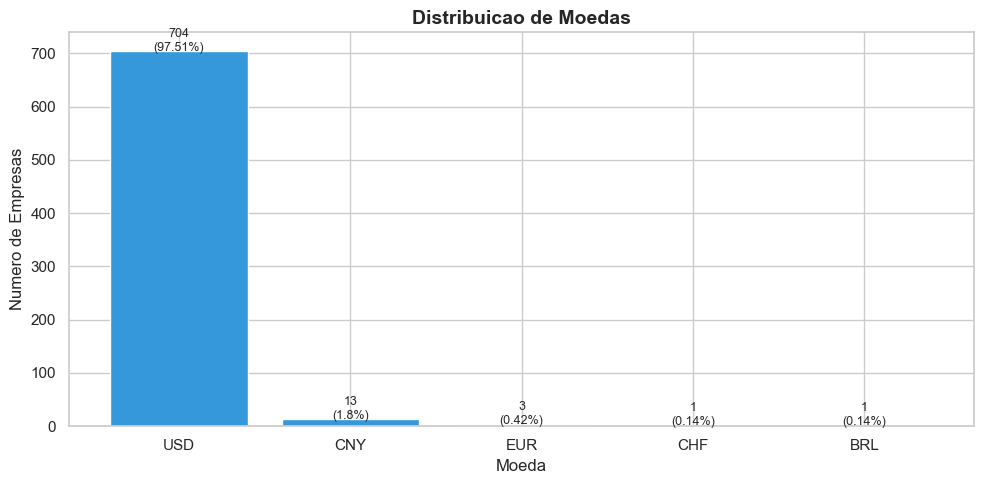

In [79]:
moedas = (
    df["currency"]
    .value_counts()
    .reset_index()
)
moedas.columns = ["Moeda", "Quantidade"]
moedas["Percentual (%)"] = (moedas["Quantidade"] / len(df) * 100).round(2)

print("DISTRIBUICAO DE MOEDAS:")
display(moedas)

# Visualizacao — barras
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(moedas["Moeda"], moedas["Quantidade"], color="#3498db")
ax.set_title("Distribuicao de Moedas", fontsize=14, fontweight="bold")
ax.set_xlabel("Moeda")
ax.set_ylabel("Numero de Empresas")

for i, (qtd, pct) in enumerate(zip(moedas["Quantidade"], moedas["Percentual (%)"])):
    ax.text(i, qtd + 1, f"{qtd}\n({pct}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_03_distribuicao_moedas.png", dpi=150, bbox_inches="tight")
plt.show()

In [80]:
moedas_raras = moedas[moedas["Quantidade"] == 1]["Moeda"].tolist()

print(f"Moedas com apenas uma empresa: {moedas_raras}\n")

empresas_raras = df[df["currency"].isin(moedas_raras)][
    ["name", "ticker", "exchange", "currency", "industry", "total_score", "total_level"]
].sort_values("currency")

print("Empresas identificadas:")
display(empresas_raras)

Moedas com apenas uma empresa: ['CHF', 'BRL']

Empresas identificadas:


,name,ticker,exchange,currency,industry,total_score,total_level
83,Afya Ltd,afya,NASDAQ NMS - GLOBAL MARKET,BRL,Diversified Consumer Services,698,Medium
37,AC Immune SA,aciu,NASDAQ NMS - GLOBAL MARKET,CHF,Biotechnology,851,Medium


> Podemos observar que neste dataset, a maioria absoluta (97,5%) das empresas estão alocadas em dólar americano (USD), e com apenas uma empresa brasileira (BRL), a Afya Ltd e uma Suíça (CHF) a AC Immune SA. Moedas com baixa representatividade podem distorcer análises comparativas por moeda

#### 5.1.2 Distribuição de Moedas

Permite identificar quais segmentos estão mais representados e possíveis vieses de amostragem.

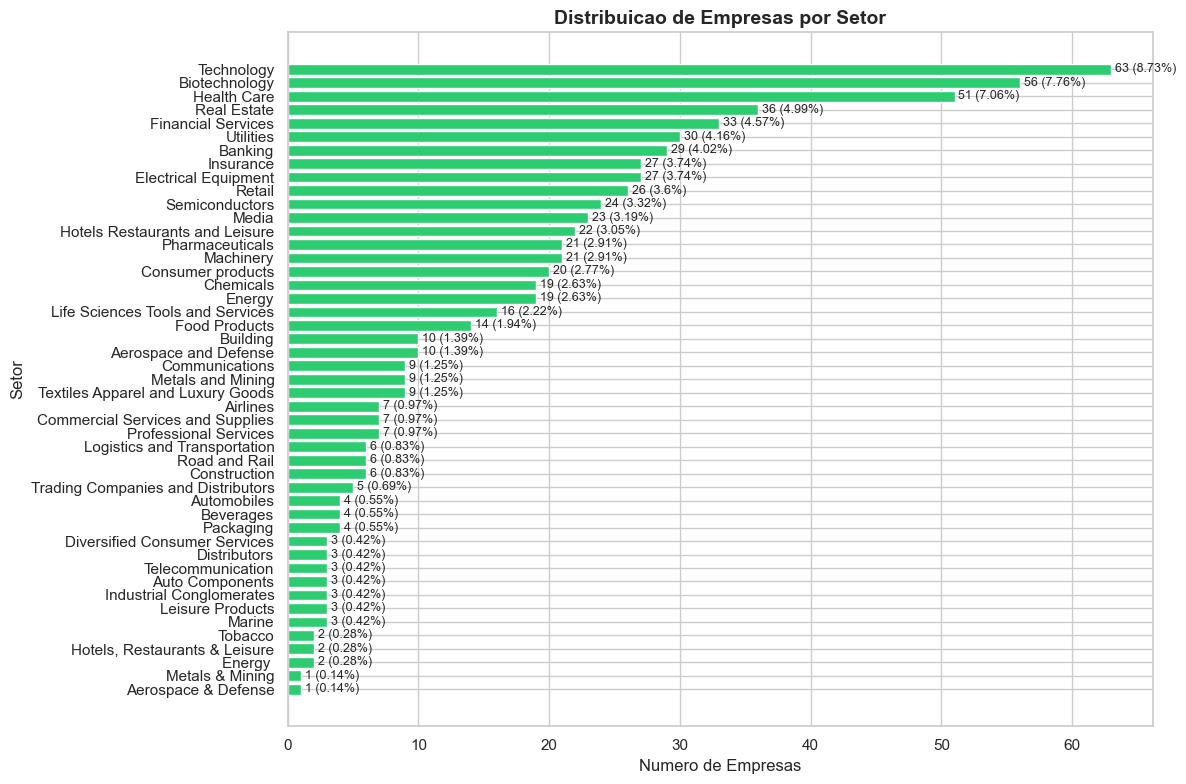

In [81]:
setores = (
    df["industry"]
    .value_counts()
    .reset_index()
)
setores.columns = ["Setor", "Quantidade"]
setores["Percentual (%)"] = (setores["Quantidade"] / len(df) * 100).round(2)

# Visualização — gráfico horizontal para melhor leitura dos nomes
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(setores["Setor"], setores["Quantidade"], color="#2ecc71")
ax.set_title("Distribuicao de Empresas por Setor", fontsize=14, fontweight="bold")
ax.set_xlabel("Numero de Empresas")
ax.set_ylabel("Setor")
ax.invert_yaxis()

for i, (qtd, pct) in enumerate(zip(setores["Quantidade"], setores["Percentual (%)"])):
    ax.text(qtd + 0.3, i, f"{qtd} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_04_distribuicao_setores.png", dpi=150, bbox_inches="tight")
plt.show()

> **Interpretação:**
- Setores com maior representatividade têm análises mais confiáveis
- Setores com poucos representantes devem ser interpretados com cautela
- Desequilíbrio entre setores é esperado e reflete a composição real do mercado

#### 5.1.3 Tendência Central e Dispersão dos Scores ESG

Objetivo de mostrar onde os dados se concentram e o quão espalhados estão ao redor desse centro.

In [82]:
cols_scores = [
    "environment_score",
    "social_score",
    "governance_score",
    "total_score"
]

# Calcula estatísticas manualmente para ter controle total sobre o que exibir
descritiva = pd.DataFrame({
    "Média"              : df[cols_scores].mean(),
    "Mediana"            : df[cols_scores].median(),
    "Moda"               : df[cols_scores].mode().iloc[0],
    "Desvio Padrão"      : df[cols_scores].std(),
    "Mínimo"             : df[cols_scores].min(),
    "Máximo"             : df[cols_scores].max(),
    "Coef. Variação (%)" : (df[cols_scores].std() / df[cols_scores].mean() * 100),
}).round(2)

descritiva.index = ["Ambiental", "Social", "Governança", "Total"]

print("TENDENCIA CENTRAL E DISPERSAO DOS SCORES ESG:")
display(descritiva)

TENDENCIA CENTRAL E DISPERSAO DOS SCORES ESG:


,Média,Mediana,Moda,Desvio Padrão,Mínimo,Máximo,Coef. Variação (%)
Ambiental,404.81,483.00,500,145.10,200,719,35.85
Social,292.18,302.00,300,57.02,160,667,19.51
Governança,278.76,300.00,300,47.03,75,475,16.87
Total,975.75,1046.00,1100,218.75,600,1536,22.42


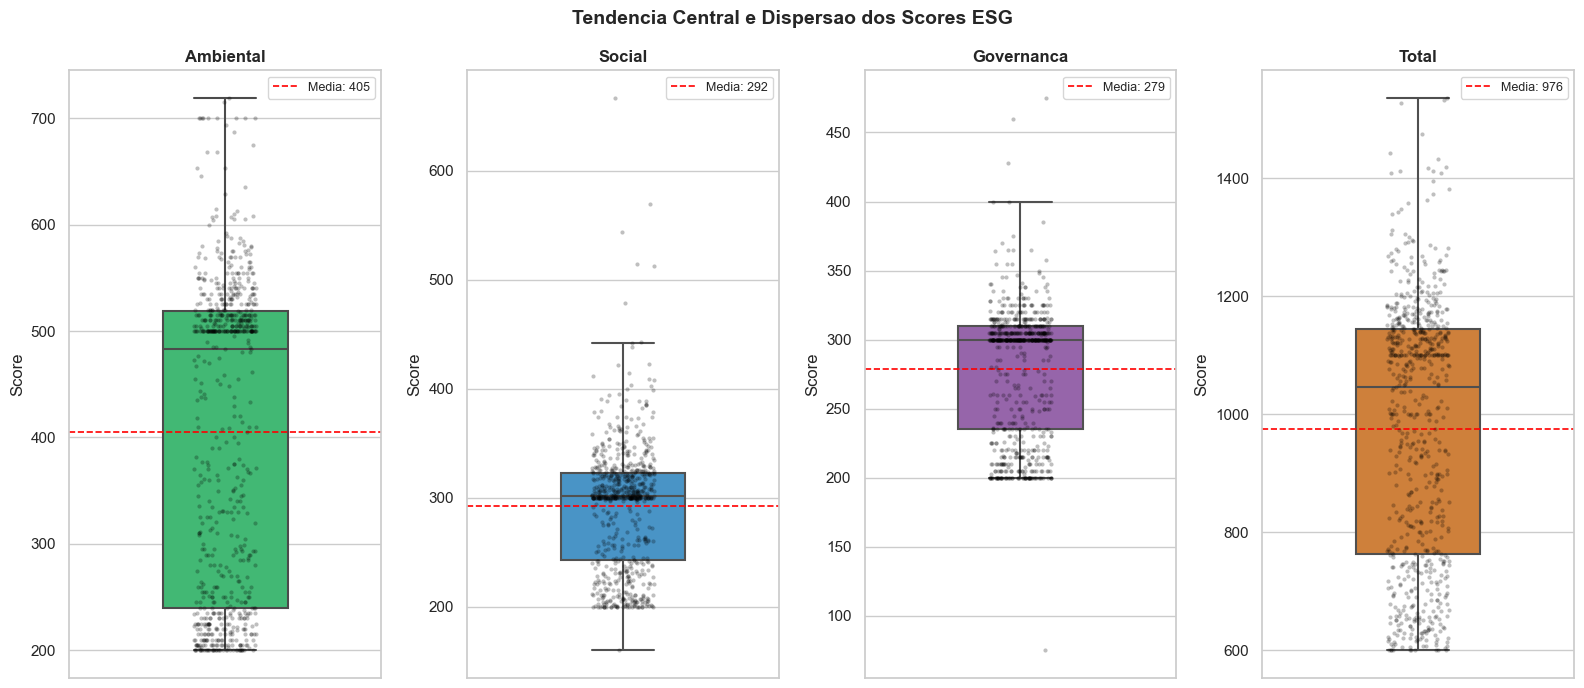

In [83]:
fig, axes = plt.subplots(1, 4, figsize=(16, 7))
fig.suptitle("Tendencia Central e Dispersao dos Scores ESG", 
             fontsize=14, fontweight="bold")

cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]
titulos = ["Ambiental", "Social", "Governanca", "Total"]

for ax, col, cor, titulo in zip(axes, cols_scores, cores, titulos):
    # Boxplot
    sns.boxplot(
        y=df[col],
        ax=ax,
        color=cor,
        width=0.4,
        fliersize=0,        # esconde os outliers do boxplot pois o stripplot ja os mostra
        linewidth=1.5
    )
    # Pontos individuais sobrepostos
    sns.stripplot(
        y=df[col],
        ax=ax,
        color="black",
        alpha=0.25,         # transparencia para visualizar sobreposicao
        size=3,
        jitter=True         # dispersao horizontal para nao empilhar pontos
    )
    # Linha da média
    media = df[col].mean()
    ax.axhline(media, color="red", linestyle="--", linewidth=1.2, label=f"Media: {media:.0f}")

    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_05_boxplot_scores.png", dpi=150, bbox_inches="tight")
plt.show()

>**Interpretação:**

**Premissas**
- A linha central da caixa representa a mediana
- A linha vermelha tracejada representa a média
- Quando média e mediana estão distantes, indica assimetria na distribuição
- Pontos muito acima ou abaixo da caixa são candidatos a outliers
- A altura da caixa (IQR) mostra onde estão os 50% centrais das empresas

**Resultados**

***<u>Score Ambiental</u>***

- Tem a maior dispersão de todos, com pontos espalhados de 200 a 700+
- Média (405) abaixo da mediana (~480), demonstrando distribuição assimétrica à esquerda, puxada por empresas com baixa performance ambiental
- <u>Esta se mostra como a dimensão onde as empresas mais se diferenciam entre si</u>

***<u>Score Social</u>***

- Distribuição mais concentrada e simétrica, com média e mediana bem próximas (~292 e ~300)
- Há poucos outliers extremos
- <u>Logo, empresas tendem a convergir em performance social</u>

***<u>Score Governança</u>***

- Demosntra a menor amplitude de todas as dimensões
- Ou seja, caixa compacta com empresas com comportamento mais homogêneo em governança
- Média (279) ligeiramente abaixo da mediana (~295)

***<u>Score Total </u>***

- Reflete a soma dos três, portanto, dispersão moderada
- Média (976) abaixo da mediana (~1030), assimetria puxada pelo score ambiental
- Outliers superiores bem visíveis, havendo empresas excepcionalmente bem avaliadas   


>**Conclusão**
>
>O score ambiental demonstra ser o fator principal de diferenciação entre empresas. Já a Governança é onde há mais homogeneidade. O que sugere que os modelos de classificação terão no score ambiental sua feature mais discriminante.
>   



#### 5.4 Média dos scores por setor

Será feita a comparação da performance ESG média entre os diferentes setores da industria. Permite identificar se correlação entre setor e performance, se há segmentos lideram e quais ficam abaixo da média geral.
Conforme avaliação no item 4. Qualidade dos Dados, os nomes de setores tinham duplicidade e serão normalizados temporariamente para fins de análise, ficando a correção definitiva para ser aplicada na camada Silver.

In [84]:
def normalizar_setor(texto):
    """
    Normalização temporária para análise — não altera o dataframe original.
    """
    if pd.isna(texto):
        return texto
    texto = texto.strip()
    texto = re.sub(r"[&]+", "and", texto)
    texto = re.sub(r"[,\.]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

# Cria coluna temporaria normalizada — df original intacto
industry_normalizada = df["industry"].apply(normalizar_setor)

cols_scores = ["environment_score", "social_score", "governance_score", "total_score"]

media_setor = (
    df[cols_scores]
    .assign(industry=industry_normalizada)
    .groupby("industry")[cols_scores]
    .mean()
    .round(2)
    .sort_values("total_score", ascending=False)
    .reset_index()
)
media_setor.columns = ["Setor", "Ambiental", "Social", "Governanca", "Total"]

print("MÉDIA DOS SCORES ESG POR SETOR (normalização temporária):")
display(media_setor)

MÉDIA DOS SCORES ESG POR SETOR (normalização temporária):


,Setor,Ambiental,Social,Governanca,Total
0,Utilities,550.97,357.40,282.27,1190.63
1,Tobacco,510.00,327.00,328.00,1165.00
2,Industrial Conglomerates,534.67,318.00,304.33,1157.00
3,Packaging,536.25,323.00,296.75,1156.00
4,Food Products,516.57,311.29,303.21,1131.07
5,Energy,515.10,308.95,293.71,1117.76
6,Distributors,525.00,277.00,307.67,1109.67
7,Construction,495.33,306.17,281.17,1082.67
8,Road and Rail,452.83,326.33,297.17,1076.33
9,Building,476.70,305.10,292.40,1074.20


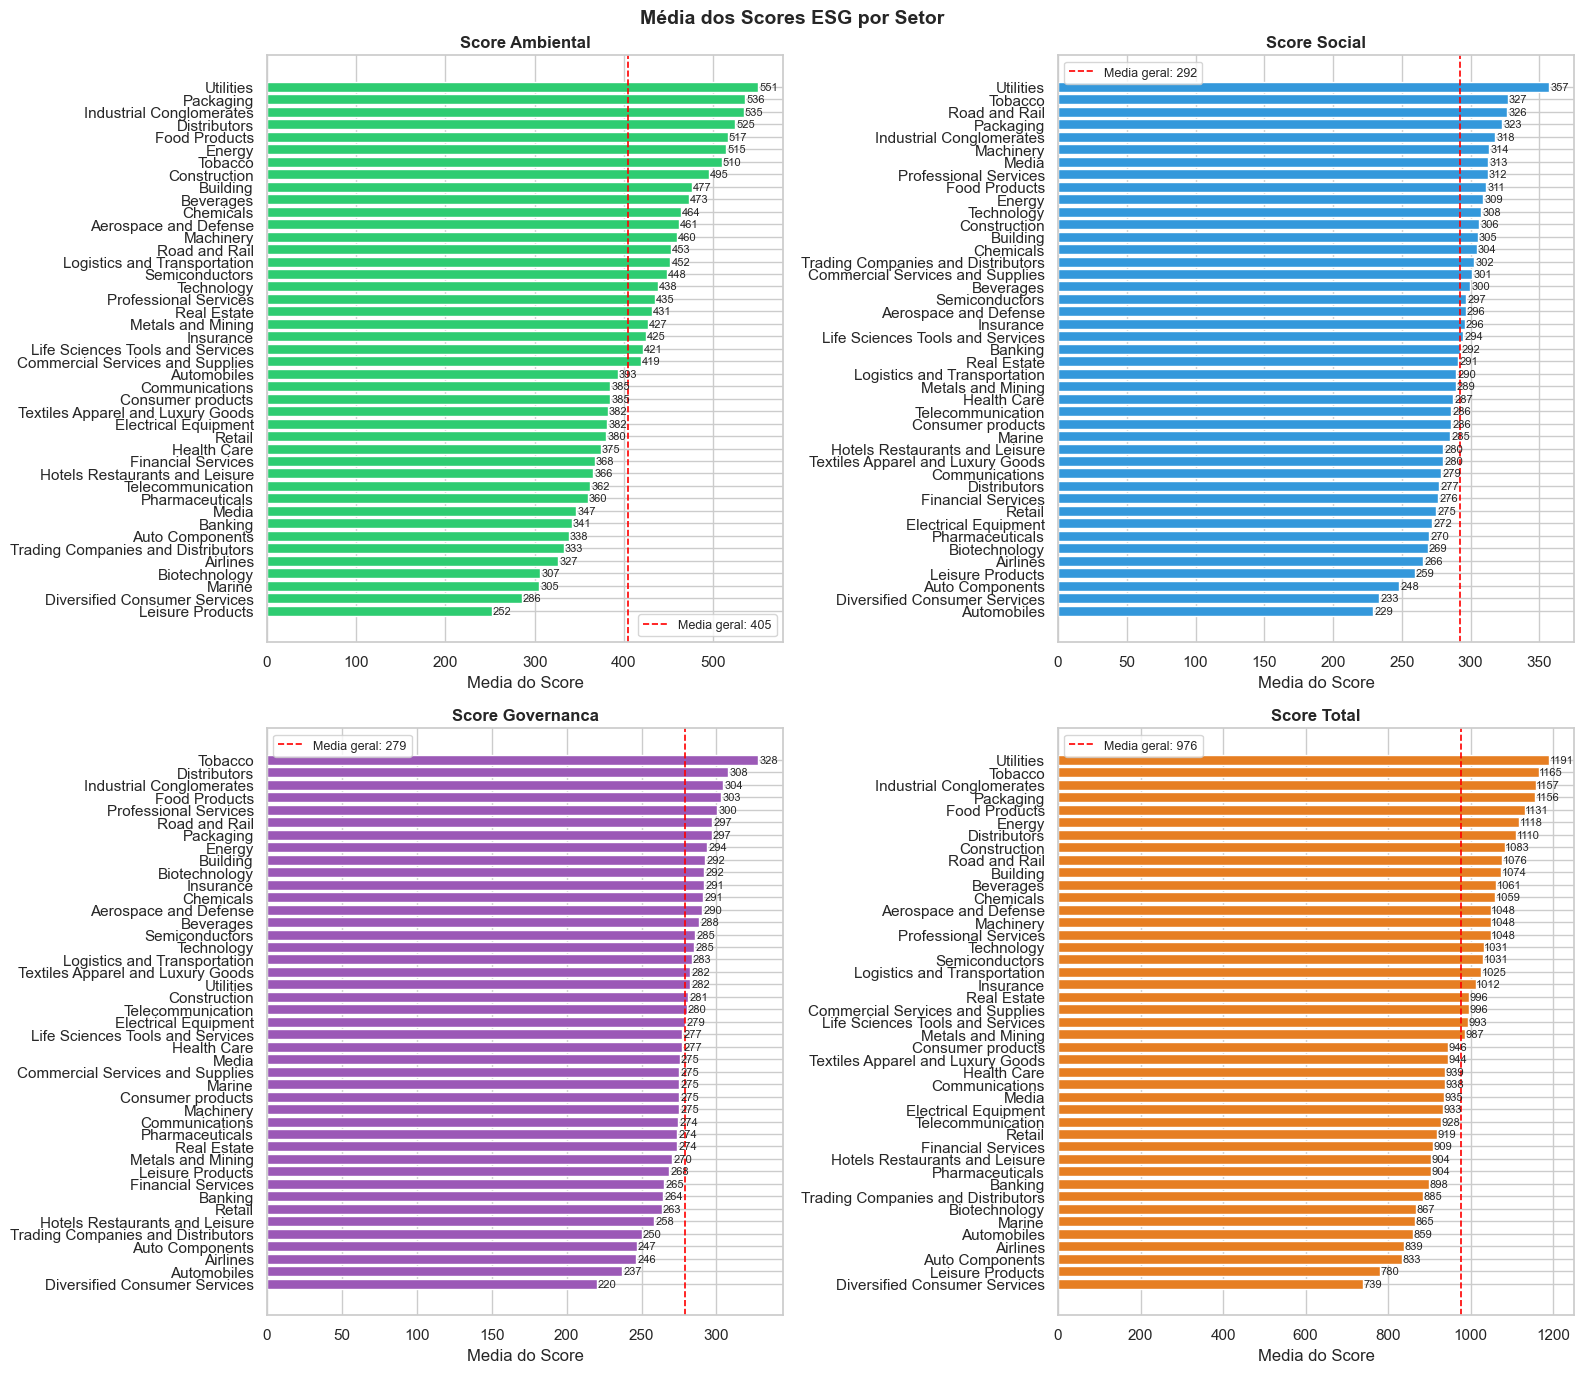

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Média dos Scores ESG por Setor", fontsize=14, fontweight="bold")

colunas_plot = ["Ambiental", "Social", "Governanca", "Total"]
cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]

for ax, coluna, cor in zip(axes.flatten(), colunas_plot, cores):
    dados = media_setor.sort_values(coluna, ascending=True)

    bars = ax.barh(dados["Setor"], dados[coluna], color=cor)
    ax.set_title(f"Score {coluna}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Media do Score")
    ax.set_ylabel("")

    media_geral = df[cols_scores[colunas_plot.index(coluna)]].mean()
    ax.axvline(
        media_geral,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"Media geral: {media_geral:.0f}"
    )

    for bar, val in zip(bars, dados[coluna]):
        ax.text(
            val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}", va="center", fontsize=8
        )

    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_06_media_scores_por_setor.png", dpi=150, bbox_inches="tight")
plt.show()

>**Interpretação:**

**Premissas**
- A linha vermelha tracejada representa a média geral de todas as empresas
- Setores acima da linha são acima da média do mercado naquela dimensão
- Setores abaixo da linha requerem maior atenção na gestão de risco ESG
- Variações entre dimensões (E, S, G) dentro do mesmo setor revelam pontos fortes e vulnerabilidades específicas de cada segmento

**Resultados**

***<u>Desempenho em total score</u>***

- Setores de **Utilidades**, **Tabaco** e **Conclomerado Industriais**, respectivamente nas primeiras três posições.
- Setores de **Serviços de Consumo Diversos**, **Produtos de Lazer** e **Linhas aéreas**, respectivamente nas últimas três posições.

***<u>Dimensão Ambiental com maior variação</u>***

- Conforme já levantado anteriormente no gráfico de *boxplot*, a área ambiental possui a maior variação, onde o líder **Utilidades** têm score de 550, enquanto a última posição **Produtos de Lazer** com score de 252, mais que a metade.

#### 5.5 Quartis, Percentis e Outliers

A análise a seguir busca principalmente a identificação de empresas ***outliers***, ou seja, com comportamento anômalo com relação ao total do grupo.


In [86]:
cols_scores = ["environment_score", "social_score", "governance_score", "total_score"]

percentis = df[cols_scores].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).T
percentis.columns = ["P10", "Q1 (P25)", "Mediana (P50)", "Q3 (P75)", "P90"]
percentis["IQR"] = percentis["Q3 (P75)"] - percentis["Q1 (P25)"]
percentis["Limite Inferior"] = (percentis["Q1 (P25)"] - 1.5 * percentis["IQR"]).round(2)
percentis["Limite Superior"] = (percentis["Q3 (P75)"] + 1.5 * percentis["IQR"]).round(2)

percentis.index = ["Ambiental", "Social", "Governanca", "Total"]

print("QUARTIS, PERCENTIS E LIMITES IQR:")
display(percentis.round(2))

QUARTIS, PERCENTIS E LIMITES IQR:


,P10,Q1 (P25),Mediana (P50),Q3 (P75),P90,IQR,Limite Inferior,Limite Superior
Ambiental,210.00,240.00,483.00,518.75,555.00,278.75,-178.12,936.88
Social,208.00,243.00,302.00,322.75,348.00,79.75,123.38,442.38
Governanca,205.00,235.00,300.00,310.00,320.00,75.00,122.50,422.50
Total,653.00,763.00,1046.00,1144.00,1207.90,381.00,191.50,1715.50


In [87]:
print("EMPRESAS IDENTIFICADAS COMO OUTLIERS POR DIMENSÃO E-S-G:\n")

outliers_total = pd.DataFrame()

for col, rotulo in zip(cols_scores, ["Ambiental", "Social", "Governança", "Total"]):
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)][
        ["name", "ticker", "industry", col, "total_level"]
    ].copy()
    outliers["dimensão"]  = rotulo
    outliers["direção"]   = outliers[col].apply(
        lambda x: "Superior" if x > lim_sup else "Inferior"
    )
    outliers["limite_inf"] = round(lim_inf, 2)
    outliers["limite_sup"] = round(lim_sup, 2)
    outliers = outliers.rename(columns={col: "score"})

    print(f"  {rotulo}: {len(outliers)} outliers "
          f"(limite: [{lim_inf:.0f}, {lim_sup:.0f}])")

    outliers_total = pd.concat([outliers_total, outliers])

print(f"\n  Total de ocorrências de outliers: {len(outliers_total)}")
print(f"  (uma empresa pode ser outlier em mais de uma dimensão)\n")
display(outliers_total.sort_values(["dimensão", "direção", "score"]).reset_index(drop=True))

EMPRESAS IDENTIFICADAS COMO OUTLIERS POR DIMENSÃO E-S-G:

  Ambiental: 0 outliers (limite: [-178, 937])
  Social: 7 outliers (limite: [123, 442])
  Governança: 4 outliers (limite: [122, 422])
  Total: 0 outliers (limite: [192, 1716])

  Total de ocorrências de outliers: 11
  (uma empresa pode ser outlier em mais de uma dimensão)



,name,ticker,industry,score,total_level,dimensão,direção,limite_inf,limite_sup
0,CMS Energy Corp,cms,Utilities,75,High,Governança,Inferior,122.50,422.50
1,Akoustis Technologies Inc,akts,Electrical Equipment,428,High,Governança,Superior,122.50,422.50
2,Amazon.com Inc,amzn,Retail,460,High,Governança,Superior,122.50,422.50
3,Amphenol Corp,aph,Electrical Equipment,475,High,Governança,Superior,122.50,422.50
4,Microsoft Corp,msft,Technology,443,High,Social,Superior,123.38,442.38
5,Pinnacle West Capital Corp,pnw,Utilities,479,High,Social,Superior,123.38,442.38
6,Edison International,eix,Utilities,513,High,Social,Superior,123.38,442.38
7,Yelp Inc,yelp,Media,515,High,Social,Superior,123.38,442.38
8,Conocophillips,cop,Energy,544,High,Social,Superior,123.38,442.38
9,Airbnb Inc,abnb,Hotels Restaurants and Leisure,570,High,Social,Superior,123.38,442.38


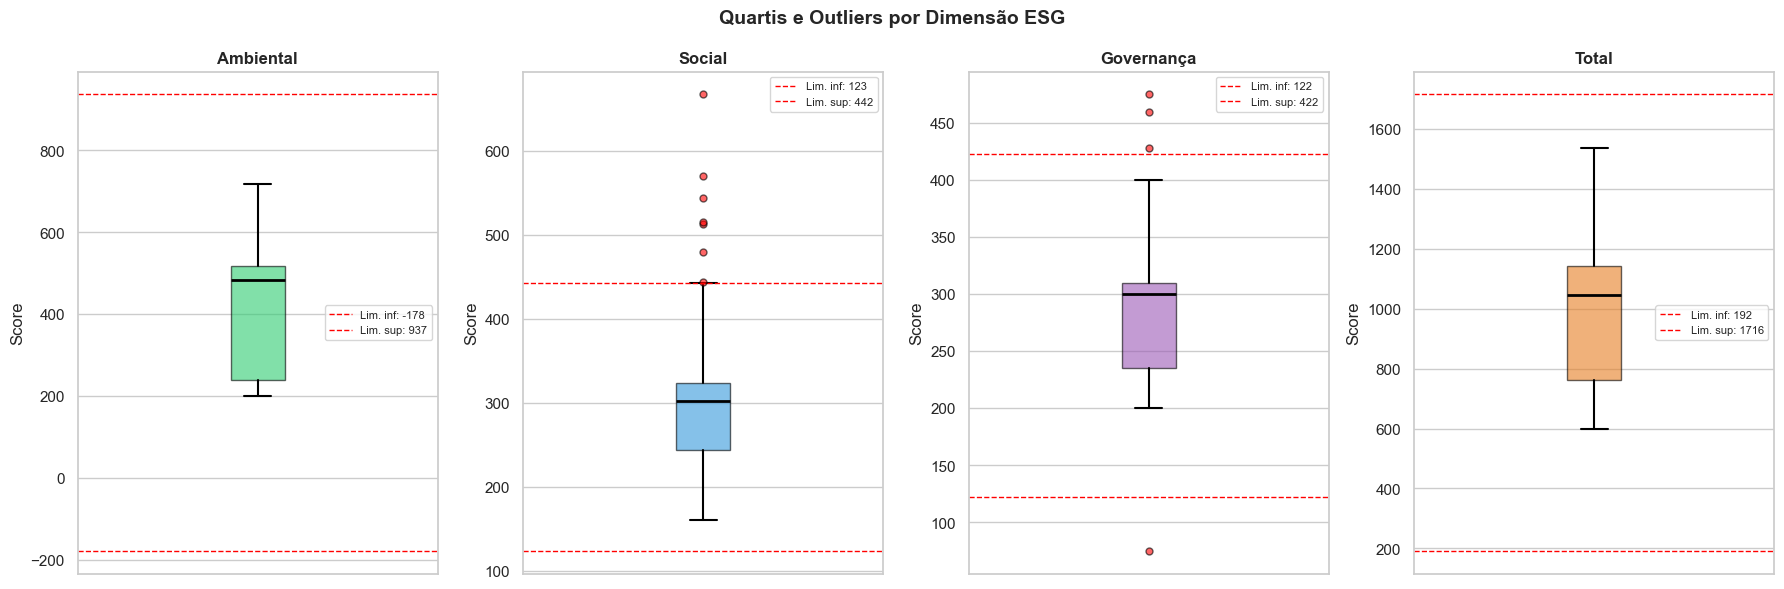

In [88]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("Quartis e Outliers por Dimensão ESG", fontsize=14, fontweight="bold")

cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]
rotulos = ["Ambiental", "Social", "Governança", "Total"]

for ax, col, cor, rotulo in zip(axes, cols_scores, cores, rotulos):
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # Boxplot
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=cor, alpha=0.6),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", markerfacecolor="red",
                        markersize=5, alpha=0.6),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )

    # Linhas dos limites IQR
    ax.axhline(lim_inf, color="red", linestyle="--",
               linewidth=1, label=f"Lim. inf: {lim_inf:.0f}")
    ax.axhline(lim_sup, color="red", linestyle="--",
               linewidth=1, label=f"Lim. sup: {lim_sup:.0f}")

    ax.set_title(rotulo, fontsize=12, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_xticks([])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../docs/viz_07_outliers_iqr.png", dpi=150, bbox_inches="tight")
plt.show()

>**Interpretação:**

**Premissas**
- O metodo IQR (Amplitude ou Intervalo Interquartil) define que outliers são os com valores abaixo do limite inferior *Q1 - (1.5*IQR)* ou acima do limite superior *Q3 + (1.5*IQR)*. Q1 é o primeiro quartil, representa 25% dos dados, e Q3 o terceiro quartil, que representa os 75%
- Outliers superiores são empresas excepcionalmente bem avaliadas, o que podem ser lideres genuínos ou erros de medição
- Outliers inferiores por outro lado, são as empresas com performance anomalamente baixa, com a possibilidade então de serem classificadas como de alto risco ESG na matriz de criticidade

**Resultados**

***<u>Score Ambiental</u>***

- Nenhum outlier detectado
- Possui a maior amplitude entre as dimensões, demonstrando haver empresas com alta e baixa performance 
- Limite inferior negativo (aprox. -200) sinalizando que o metodo IQR sozinho é insuficiente avaliar para esta dimensão

***<u>Score Social</u>***

- 7 outliers superiores $^2$

***<u>Score Governança</u>***

- 3 outliers superiores
- 1 outlier inferior $^2$

***<u>Score total</u>***

- Nenhum outlier

$^2$ ***CMS Energy Corp***: Demonstrou ter uma peformance assimétrica, sendo um ***outlier superior*** para a dimensão **Social**, porém, também sendo um ***outlier inferior*** na dimensão **Governança**

### 5.2 Analise Inferencial

Procuraremos a partir desta sessão, tentar retirar alguma generalização a partir dos dados que temos como amostra para responder as seguintes questões:
- Empresas boas em uma dimensão, tendem a também serem boas nas demais?
- Há correlação entre performance em ESG e setores?

#### 5.2.1 Teste de normalidade

Primeiramente, é necessário responder a seguinte questão: *Os dados seguem distribuição normal?* se sim, iremos usar testes paramétricos, se não, serão usados testes não paramétricos, para responder as questões levantadas.

> Teste utilizado: Shapiro-Wilk
> - Hipotese nula (H0): os dados seguem distribuicao normal
> - Hipotese alternativa (H1): os dados nao seguem distribuicao normal
> - Nivel de significancia: 0.05
> - Se p-valor < 0.05: rejeita H0 — distribuicao nao e normal
> - Se p-valor >= 0.05: nao rejeita H0 — distribuicao pode ser normal

TESTE DE NORMALIDADE
Nível de significância: 0.05

  Ambiental
    Estatística W : 0.8776
    p-valor       : 0.000000
    Conclusao     : Não normal (p < 0.05)

  Social
    Estatística W : 0.9138
    p-valor       : 0.000000
    Conclusao     : Não normal (p < 0.05)

  Governanca
    Estatística W : 0.8742
    p-valor       : 0.000000
    Conclusao     : Não normal (p < 0.05)

  Total
    Estatística W : 0.9361
    p-valor       : 0.000000
    Conclusao     : Não normal (p < 0.05)


RESUMO:


,Dimensão,Estatística,p-valor,Normal?,Conclusão
0,Ambiental,0.88,0.00,Nao,Não normal
1,Social,0.91,0.00,Nao,Não normal
2,Governanca,0.87,0.00,Nao,Não normal
3,Total,0.94,0.00,Nao,Não normal


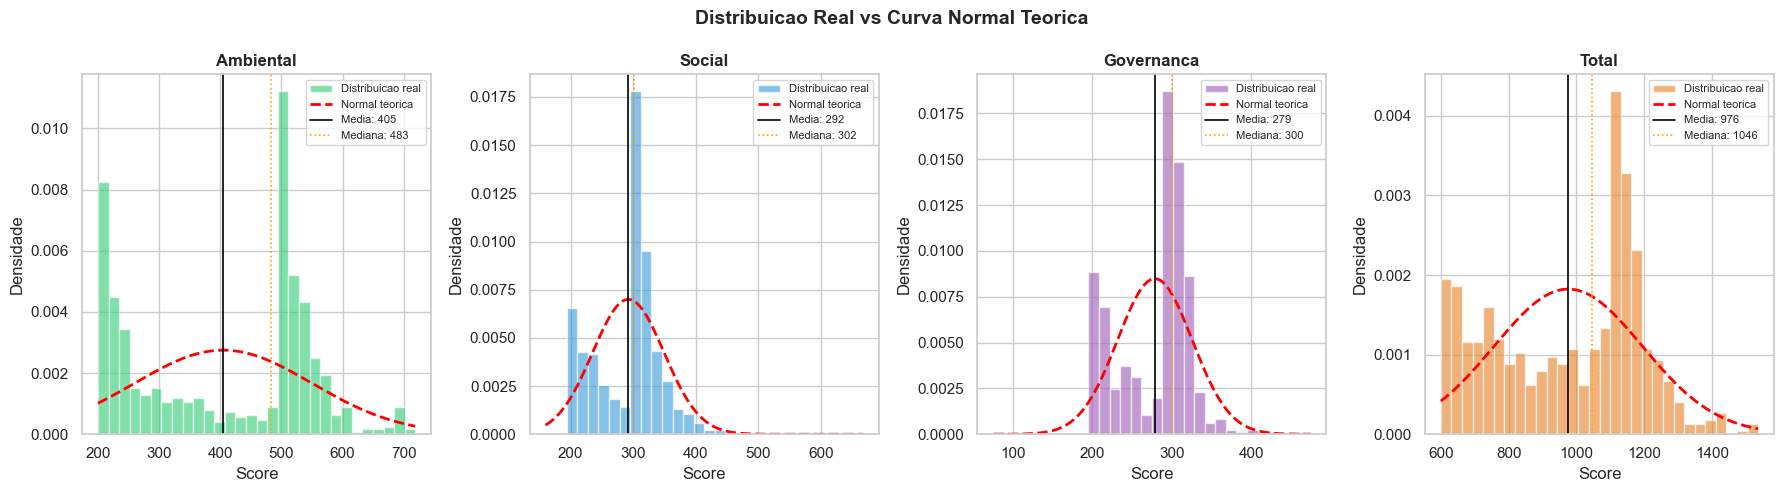

In [89]:
from scipy import stats

cols_scores = ["environment_score", "social_score", 
               "governance_score", "total_score"]
rotulos     = ["Ambiental", "Social", "Governanca", "Total"]

print("=" * 60)
print("TESTE DE NORMALIDADE")
print("Nível de significância: 0.05")
print("=" * 60)

resultados_normalidade = []

for col, rotulo in zip(cols_scores, rotulos):
    stat, p_valor = stats.shapiro(df[col].dropna())
    normal        = p_valor >= 0.05
    conclusao     = "Normal" if normal else "Não normal"

    resultados_normalidade.append({
        "Dimensão"   : rotulo,
        "Estatística": round(stat, 4),
        "p-valor"    : round(p_valor, 6),
        "Normal?"    : "Sim" if normal else "Nao",
        "Conclusão"  : conclusao
    })

    print(f"\n  {rotulo}")
    print(f"    Estatística W : {stat:.4f}")
    print(f"    p-valor       : {p_valor:.6f}")
    sinal = "<" if p_valor < 0.05 else ">="
    print(f"    Conclusao     : {conclusao} (p {sinal} 0.05)")

df_normalidade = pd.DataFrame(resultados_normalidade)
print("\n")
print("RESUMO:")
display(df_normalidade)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Distribuicao Real vs Curva Normal Teorica", 
             fontsize=14, fontweight="bold")

cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]

for ax, col, rotulo, cor in zip(axes, cols_scores, rotulos, cores):
    dados = df[col].dropna()
    media = dados.mean()
    desvio = dados.std()

    # Histograma normalizado (densidade)
    ax.hist(dados, bins=30, color=cor, alpha=0.6, density=True, label="Distribuicao real")

    # Curva normal teorica com mesma media e desvio
    x = np.linspace(dados.min(), dados.max(), 200)
    curva_normal = stats.norm.pdf(x, media, desvio)
    ax.plot(x, curva_normal, color="red", linewidth=2, linestyle="--", label="Normal teorica")

    # Linhas de media e mediana
    ax.axvline(media,         color="black",  linewidth=1.2, linestyle="-",  label=f"Media: {media:.0f}")
    ax.axvline(dados.median(), color="orange", linewidth=1.2, linestyle=":",  label=f"Mediana: {dados.median():.0f}")

    ax.set_title(rotulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../docs/viz_09_distribuicao_vs_normal.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretação**

Todas as dimensões ESG apresentam p-valor < 0.05, rejeitando a hipótese nula de normalidade em todas elas.

#### 5.2.2 Correlações (E x S, E x G, S x G)

Será utilizado o coeficiente de Spearman, uma vez que se torna mais adequado para dados não normais e procurarmos relação entre duas variáveis numéricas

> Interpretação do coeficiente de Spearman (rho):
> - 0.00 a 0.19 : correlação muito fraca
> - 0.20 a 0.39 : correlação fraca
> - 0.40 a 0.59 : correlação moderada
> - 0.60 a 0.79 : correlação forte
> - 0.80 a 1.00 : correlação muito forte
> - Sinal negativo: correlação inversa

In [90]:
from scipy.stats import spearmanr

pares = [
    ("environment_score", "social_score",      "Ambiental x Social"),
    ("environment_score", "governance_score",  "Ambiental x Governanca"),
    ("social_score",      "governance_score",  "Social x Governanca"),
]

print("=" * 60)
print("CORRELAÇÃO DE SPEARMAN ENTRE DIMENSÕES ESG")
print("NÍvel de significância: 0.05")
print("=" * 60)

resultados_corr = []

for col_x, col_y, rotulo in pares:
    rho, p_valor = spearmanr(df[col_x].dropna(), df[col_y].dropna())

    if abs(rho) < 0.20:
        forca = "Muito fraca"
    elif abs(rho) < 0.40:
        forca = "Fraca"
    elif abs(rho) < 0.60:
        forca = "Moderada"
    elif abs(rho) < 0.80:
        forca = "Forte"
    else:
        forca = "Muito forte"

    direcao      = "positiva" if rho > 0 else "negativa"
    significativa = "Sim" if p_valor < 0.05 else "Não"
    resultados_corr.append({
        "Par"              : rotulo,
        "Spearman (rho)"   : round(rho, 4),
        "p-valor"          : round(p_valor, 6),
        "Forca"            : forca,
        "Direcao"          : direcao,
        "Significativa?"   : significativa
    })

    print(f"\n  {rotulo}")
    print(f"    Spearman rho  : {rho:.4f}")
    print(f"    p-valor       : {p_valor:.6f}")
    print(f"    Forca         : {forca} e {direcao}")
    print(f"    Significativa : {significativa}")

df_correlacoes = pd.DataFrame(resultados_corr)
print("\nRESUMO:")
display(df_correlacoes)

CORRELAÇÃO DE SPEARMAN ENTRE DIMENSÕES ESG
NÍvel de significância: 0.05

  Ambiental x Social
    Spearman rho  : 0.7033
    p-valor       : 0.000000
    Forca         : Forte e positiva
    Significativa : Sim

  Ambiental x Governanca
    Spearman rho  : 0.5622
    p-valor       : 0.000000
    Forca         : Moderada e positiva
    Significativa : Sim

  Social x Governanca
    Spearman rho  : 0.5795
    p-valor       : 0.000000
    Forca         : Moderada e positiva
    Significativa : Sim

RESUMO:


,Par,Spearman (rho),p-valor,Forca,Direcao,Significativa?
0,Ambiental x Social,0.70,0.00,Forte,positiva,Sim
1,Ambiental x Governanca,0.56,0.00,Moderada,positiva,Sim
2,Social x Governanca,0.58,0.00,Moderada,positiva,Sim


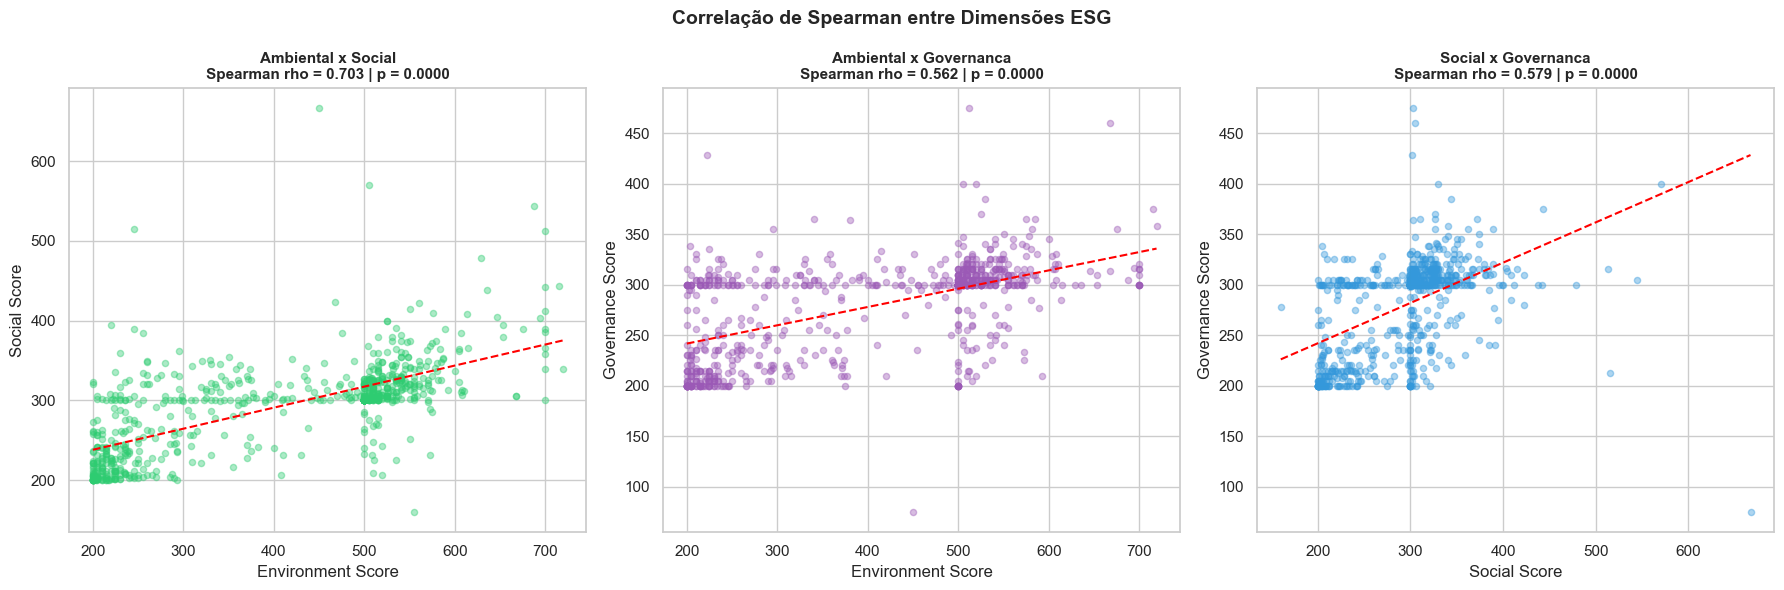

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Correlação de Spearman entre Dimensões ESG",
             fontsize=14, fontweight="bold")

cores_pares = ["#2ecc71", "#9b59b6", "#3498db"]

for ax, (col_x, col_y, rotulo), cor in zip(axes, pares, cores_pares):
    rho, p_valor = spearmanr(df[col_x], df[col_y])

    ax.scatter(df[col_x], df[col_y], alpha=0.4, color=cor, s=20)

    # Linha de tendencia
    z = np.polyfit(df[col_x], df[col_y], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col_x].min(), df[col_x].max(), 200)
    ax.plot(x_line, p(x_line), color="red", linewidth=1.5, linestyle="--")

    ax.set_title(f"{rotulo}\nSpearman rho = {rho:.3f} | p = {p_valor:.4f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel(col_x.replace("_", " ").title())
    ax.set_ylabel(col_y.replace("_", " ").title())

plt.tight_layout()
plt.savefig("../docs/viz_10_correlacoes_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

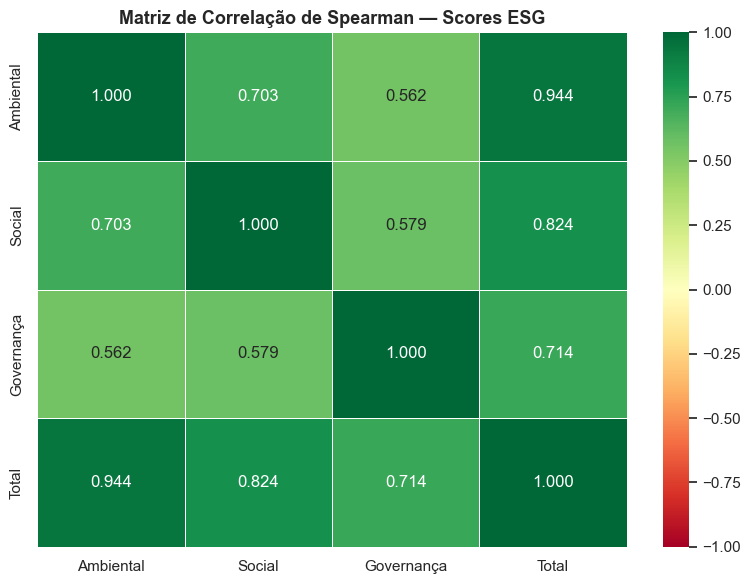

In [92]:
# Matriz de correlacao completa entre todos os scores
matriz_corr = df[cols_scores].corr(method="spearman").round(3)
matriz_corr.index   = ["Ambiental", "Social", "Governança", "Total"]
matriz_corr.columns = ["Ambiental", "Social", "Governança", "Total"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de Correlação de Spearman — Scores ESG",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../docs/viz_11_heatmap_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

> **Interpretação dos resultados**

- Todos os pares apresentaram correlação positiva e estatisticamente significativa (p-valor ≈ 0), confirmando que as três dimensões ESG estão interligadas.

***<u>Ambiental × Social (rho = 0.703) => Correlação forte:</u>***
- É o par mais correlacionado entre as dimensões independentes
- Demonstra-se que empresas com boas práticas ambientais tendem fortemente a ter boas práticas sociais, supõe-se que possa haver uma cultura ESG integrada

***<u>*Ambiental × Governança (rho = 0.562) => Correlação moderada:</u>***
- Pode-se supor que governança é mais influenciada por pressão regulatória e estrutura societária do que por cultura ESG, o que explica a correlação menor

***<u>Social × Governança (rho = 0.579) => Correlação moderada:</u>***
- Comportamento similar ao par Ambiental × Governança
- Governança é a dimensão mais "independente" das três

***<u>Correlações com o Total:</u>***
- Ambiental × Total (0.944): altíssima. O score ambiental é o principal determinante do score total.
- Social × Total (0.824): forte. É a segunda dimensão mais determinante
- Governança × Total (0.714): forte. Porém a menos determinante das três

#### 5.2.3 Correlação Setor x scores

Será utilizado o Teste de Kruskal-Wallis, uma vez que se torna mais adequado para dados não normais e procurarmos a ocorrência de diferenças entre três ou mais grupos, entre variáveis categórica e numérica (setor x score)

> Teste utilizado: 
> - **Hipótese nula (H0):** todos os setores têm a mesma distribuição de scores
> - **Hipótese alternativa (H1):** pelo menos um setor se distribui diferentemente
> - **Nível de significância:** 0.05
> - **Se p-valor < 0.05:** rejeita H0 — há diferença significativa entre setores

In [93]:
from scipy.stats import kruskal

# Aplica normalização temporária de setores (mesma lógica da seção 5.4)
industry_normalizada = df["industry"].apply(normalizar_setor)

print("=" * 60)
print("KRUSKAL-WALLIS — SETOR x SCORES ESG")
print("Nível de significância: 0.05")
print("=" * 60)

resultados_kw_setor = []

for col, rotulo in zip(cols_scores, rotulos):
    # Agrupa scores por setor normalizado
    grupos = [
        group[col].values
        for _, group in df.assign(industry=industry_normalizada).groupby("industry")
        if len(group) > 1  # exclui setores com apenas 1 empresa
    ]

    stat, p_valor = kruskal(*grupos)
    significativo = p_valor < 0.05

    resultados_kw_setor.append({
        "Dimensão"       : rotulo,
        "Estatística H"  : round(stat, 4),
        "p-valor"        : round(p_valor, 6),
        "Significativo?" : "Sim" if significativo else "Não",
        "Conclusão"      : "Setores diferem" if significativo else "Setores similares"
    })

    print(f"\n  {rotulo}")
    print(f"    Estatística H : {stat:.4f}")
    print(f"    p-valor       : {p_valor:.6f}")
    sinal = "<" if p_valor < 0.05 else ">="
    print(f"    Conclusão     : {'Diferença significativa' if significativo else 'Sem diferença significativa'} (p {sinal} 0.05)")

df_kw_setor = pd.DataFrame(resultados_kw_setor)
print("\nRESUMO:")
display(df_kw_setor)

KRUSKAL-WALLIS — SETOR x SCORES ESG
Nível de significância: 0.05

  Ambiental
    Estatística H : 146.3877
    p-valor       : 0.000000
    Conclusão     : Diferença significativa (p < 0.05)

  Social
    Estatística H : 91.0837
    p-valor       : 0.000017
    Conclusão     : Diferença significativa (p < 0.05)

  Governanca
    Estatística H : 55.8564
    p-valor       : 0.074549
    Conclusão     : Sem diferença significativa (p >= 0.05)

  Total
    Estatística H : 121.2230
    p-valor       : 0.000000
    Conclusão     : Diferença significativa (p < 0.05)

RESUMO:


,Dimensão,Estatística H,p-valor,Significativo?,Conclusão
0,Ambiental,146.39,0.00,Sim,Setores diferem
1,Social,91.08,0.00,Sim,Setores diferem
2,Governanca,55.86,0.07,Não,Setores similares
3,Total,121.22,0.00,Sim,Setores diferem


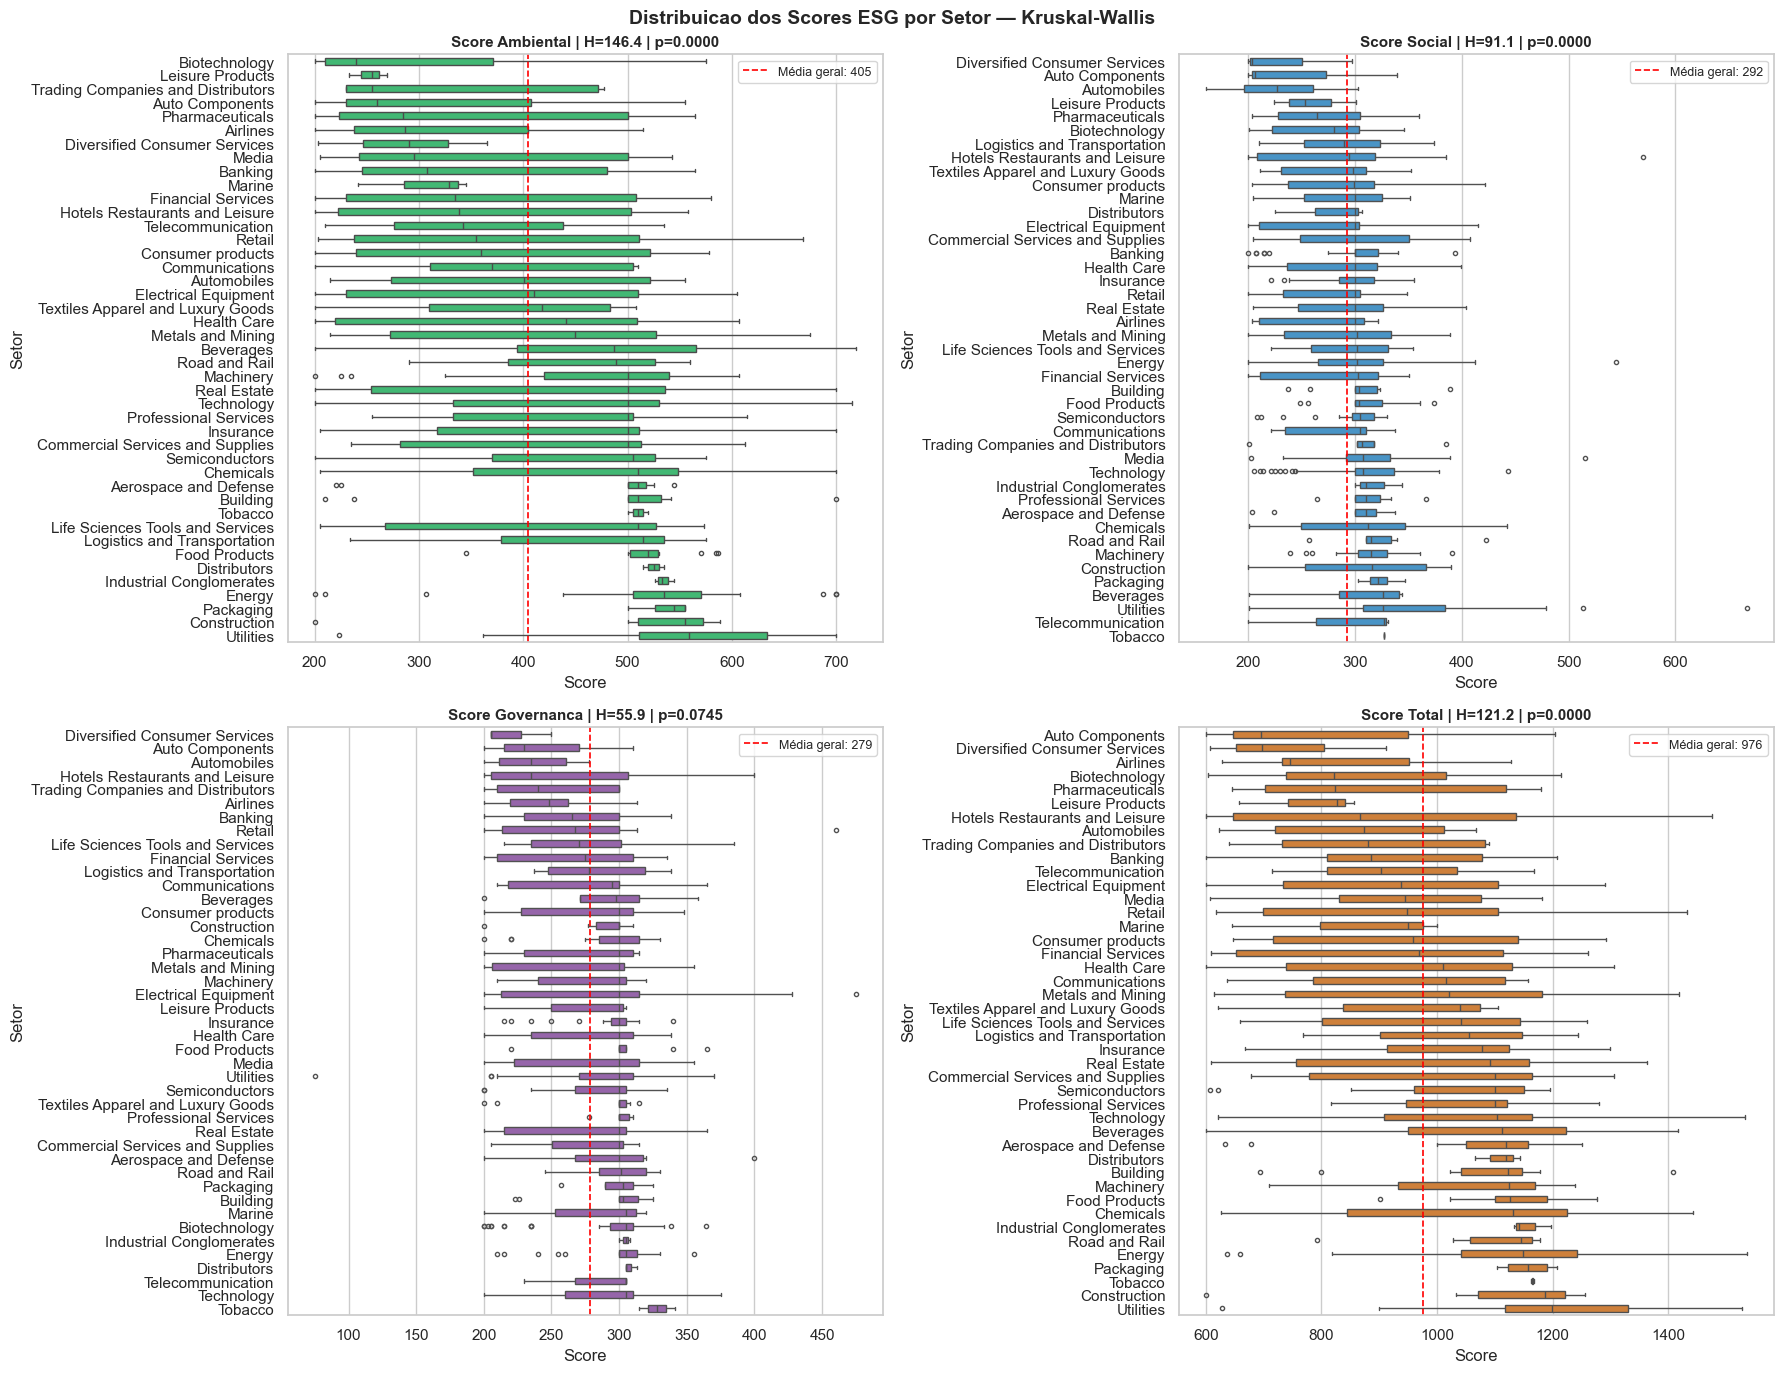

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Distribuicao dos Scores ESG por Setor — Kruskal-Wallis",
             fontsize=14, fontweight="bold")

cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]

# Reconstrói dataframe com industry normalizada para o plot
df_plot = df.copy()
df_plot["industry"] = industry_normalizada

# Ordena setores pela mediana do total_score para consistência visual
ordem_setores = (
    df_plot.groupby("industry")["total_score"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

for ax, col, rotulo, cor in zip(axes.flatten(), cols_scores, rotulos, cores):
    # Mediana por setor para ordenação individual
    ordem = (
        df_plot.groupby("industry")[col]
        .median()
        .sort_values(ascending=True)
        .index.tolist()
    )

    sns.boxplot(
        data=df_plot,
        y="industry",
        x=col,
        order=ordem,
        ax=ax,
        color=cor,
        width=0.5,
        fliersize=3,
        linewidth=1
    )

    # Linha da média geral
    media_geral = df[col].mean()
    ax.axvline(
        media_geral,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"Média geral: {media_geral:.0f}"
    )

    # Resultado do teste no título
    stat, p_valor = kruskal(*[
        group[col].values
        for _, group in df_plot.groupby("industry")
        if len(group) > 1
    ])

    ax.set_title(
        f"Score {rotulo} | H={stat:.1f} | p={p_valor:.4f}",
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Score")
    ax.set_ylabel("Setor")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_12_kruskal_setor.png", dpi=150, bbox_inches="tight")
plt.show()

> **Interpretação:**

**Premissas**

- Um valor "Estatística H" mais alta indica maior divergência entre os grupos
- Setores com caixas estreitas têm empresas homogêneas entre si
- Setores com caixas largas têm grande variação interna, o que indica que saber o setor terá pouca influência para prever o score da empresa
- Este resultado pode validar o uso do `setor` como feature na modelagem de ML

**Resultados**


***<u>Score Ambiental (H=146.4, p≈0.000)</u>***
- Diferença altamente significativa
- A maior Estatística H de todas as dimensões, o que significa que setores diferem entre si em performance ambiental mais do que em qualquer outra dimensão
- Confirma e valida estatisticamente o que observamos visualmente na seção 5.4
- <u>Para a dimensão ambiental, o setor é um forte preditor do score</u>

***<u>Score Social (H=91.1, p≈0.000)</u>***
- Diferença significativa
- Há diferenças entre setores, porém menos pronunciadas que no ambiental

***<u>Score Governança (H=55.9, p=0.075)</u>***
- Sem diferença significativa
- Único caso onde p > 0.05 , não rejeitamos H0
- Pode-se supor inicialmente que as diferenças de governança entre setores podem ser explicadas então pelo acaso, não havendo indícios de correlação, ou seja, o setor da empresa não determina sua performance em governança

***<u>Score Total (H=121.2, p≈0.000)</u>***
- Diferença significativa
- Resultado esperado devido a influência do ambiental e social


>***<u>Conclusão:</u>***
- O setor é um preditor válido para as dimensões ambiental e social, e por consequência, total. Porém não para governança.
- Na construção da matriz de criticidade de fornecedores, o setor pode ser considerado como fator de risco para E e S, mas não como determinante isolado de G.

## 6. Tratamento dos Dados

Iremos aqui documentar a etapa de tratamento de dados, que compõe a transformação Silver da arquitetura medalhão adotada. A transformação ocorrerá via scrip `src/silver_transform.py`, sendo aqui resgistrado não o código, mas apenas as etapas que serão realizadas e as premissas consideradas.

>A etapa Silver é uma etapa de transformação de dados com o objetivo de se normalizar ou corrigir problemas detectados na EDA e também eliminar dados desnecessários, para deixar o arquivo mais leve para armazenamento e processamento.

### 6.1 Pipeline de Transformação de Dados

Abaixo, todas as transformações que irão ocorrer para a camada Silver:


1. Carrega o dado bruto de `data/bronze/data.csv`

   ↓

2. Descarta colunas sem utilidade  
   - `logo`  
   - `weburl`  
   - `currency`  
   - `exchange`

   ↓

3. Reordena colunas 
   - `cik`
   - `ticker`
   - `name`
   - `industry`
   - `environment_grade`
   - `environment_level`
   - `environment_score`
   - `social_grade`
   - `social_level`
   - `social_score`
   - `governance_grade`
   - `governance_level`
   - `governance_score`
   - `total_grade`
   - `total_level`
   - `total_score`
   - `last_processing_date`

   ↓

4. Corrige inconsistências em `industry`  
   - Padroniza grafias diferentes (and, & e " ")

   ↓

5. Preenche valores nulos em `industry`  
   - Busca informações via `yfinance` usando o ticker  
   - Fallback para `"Unknown"`

   ↓

6. Converte `last_processing_date` para `datetime`


7. Salva o resultado em `data/silver/data_silver.csv`

   ↓

8. Registra `metadata_silver.json`

> ***Resultado***

Manteve-se o mesmo formato de arquivo .csv. Transformações bem sucedida, com exceção para o preenchimento dos setores em `industry`, sendo preenchidos apenas 4 nulos via yfinance (Armada, AIB, Alignment, Artisan). Outros 9 nulos foram imputados como Unknown. 

As empresas não encontradas têm um padrão no nome:

Acri Capital Acquisition Corp  
ACE Convergence Acquisition Corp  
Edoc Acquisition Corp  
AF Acquisition Corp  
Sports Ventures Acquisition Corp  
Health Assurance Acquisition Corp  
Healthcare Services Acquisition Corp  
Powered Brands  
Concord Acquisition Corp  

A palavra "Acquisition Corp" aparece na maioria, são SPACs (Special Purpose Acquisition Companies), empresas de capital aberto criadas especificamente para adquirir outras empresas. Muitas já foram dissolvidas ou incorporadas, por isso o Yahoo Finance não as encontra mais. 
Sendo uma quantidade pequena, foi feita uma pesquisa e verificou-se que estas 9 se encaixariam bem como *Financial Services* e por a quantidade ser pequena, foi alterado manualmente no código.